This is the sample code to simnulae the ShacklHartman sensor performance with a n=4 Zernike polynomials.

The externsion to the Astigmatism case is left as an exercise.


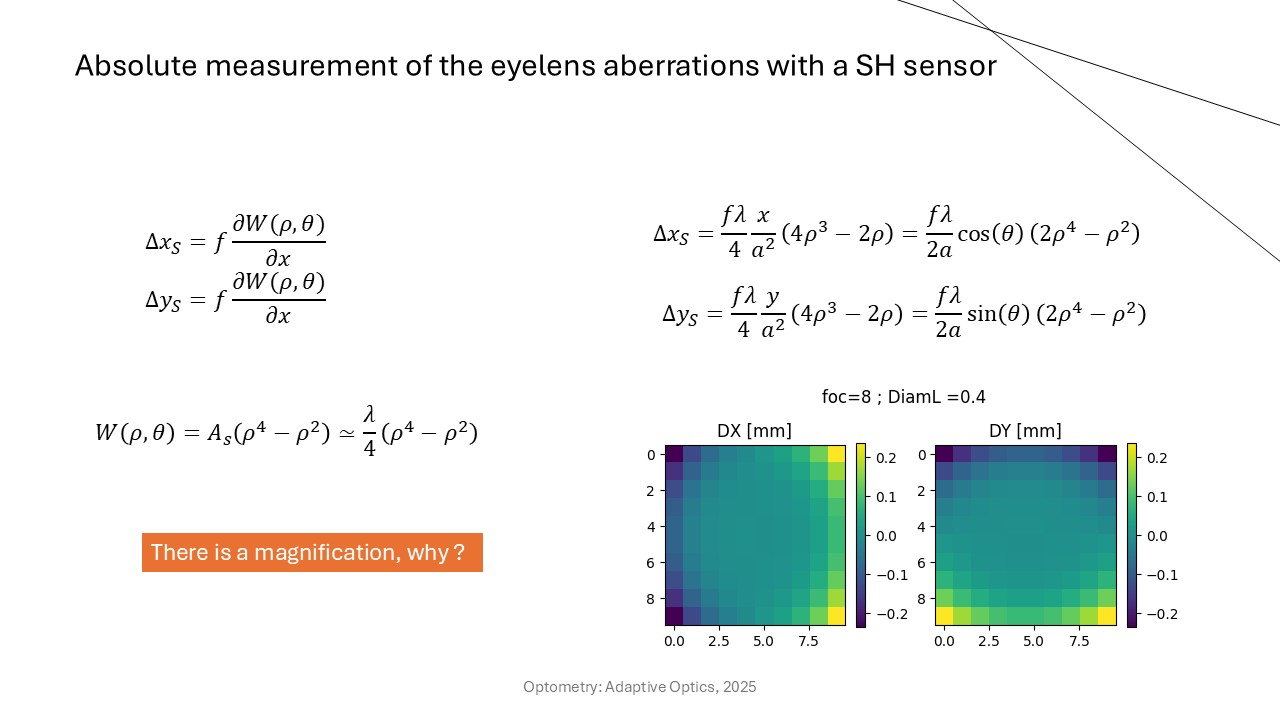

In [4]:
'''
March 2025
Giberto Chirico
This loads a sample image (whatever), RGB and comnvert it in gray scale,
then perform the FFT in 2D.
This is thought to be in colab.
to load an image, first load the image in the "content" folder on colab.
then copy the exacgtf path of the file (right click -> copy path)
'''

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt



<>:42: SyntaxWarning: invalid escape sequence '\D'
<>:45: SyntaxWarning: invalid escape sequence '\D'
<>:42: SyntaxWarning: invalid escape sequence '\D'
<>:45: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_10147/1491408748.py:42: SyntaxWarning: invalid escape sequence '\D'
  A[0].set_title('$\Delta x_S$ [mm]')
/tmp/ipykernel_10147/1491408748.py:45: SyntaxWarning: invalid escape sequence '\D'
  A[1].set_title('$\Delta y_S$ [mm]')


FOV on SHartman is  4.0  [mm]
pupil size - diameter:  6  [mm]
Magnification:  2


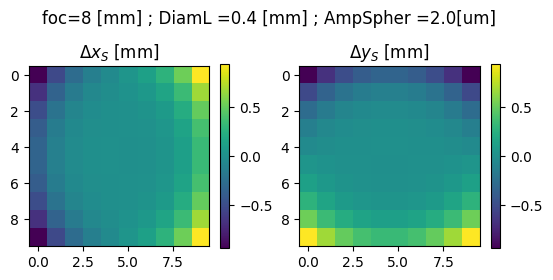

In [21]:
from os import X_OK
############ definition of the SHack Hartman parameters

focal   =  8 #mm
waveL   = 0.5 # um
DiamL   = 0.4 #mm  diameter if the microlenses

Nlens   = 10   ## number of the microlenses

Magnif  = 2     #### if we have a magnification !

pupil   = 3 ### mm


SD      = Nlens * DiamL   #overall size of the beam pupil on the SH sensor
print ('FOV on SHartman is ',SD,' [mm]')
print ('pupil size - diameter: ', pupil*2 , ' [mm]')
Magnif = 1+ int(2*pupil/SD)
print ('Magnification: ',Magnif)

x       = np.linspace(-SD,SD,Nlens)
y       = x
xx,yy   = np.meshgrid(x,y)

rho     = np.sqrt(xx**2 + yy**2)
angolo  = np.arctan2(yy,xx)

DXY     = np.zeros((Nlens,Nlens,2))    #### array of the displacements on the microlenses
# it contains Delta_x_s and DElta_y_s as 0 and 1 comnponent
### we assume an amplitude of spherical aberrations = lambda
AmpSpher    = 4* waveL   ## um

DXY[:,:,0]  = 0.001 *  focal * AmpSpher * waveL * np.cos(angolo) *(rho**4 - 0.5*rho**2) / pupil /Magnif
DXY[:,:,1]  = 0.001 * focal * AmpSpher * waveL * np.sin(angolo) *(rho**4 - 0.5*rho**2) / pupil / Magnif ## in mm


######## show the results
Stitle  = 'foc=' + str(focal)+' [mm] ; DiamL ='+str(DiamL)+' [mm] ; AmpSpher ='+str(AmpSpher)+'[um]'

F,A = plt.subplots (1,2)
im0 = A[0].imshow(DXY[:,:,0])
A[0].set_title('$\Delta x_S$ [mm]')
plt.colorbar(im0,ax=A[0],shrink = 0.5)
im1 = A[1].imshow(DXY[:,:,1])
A[1].set_title('$\Delta y_S$ [mm]')
plt.colorbar(im1,ax=A[1],shrink = 0.5)
F.suptitle(Stitle,y=0.8)
plt.show()



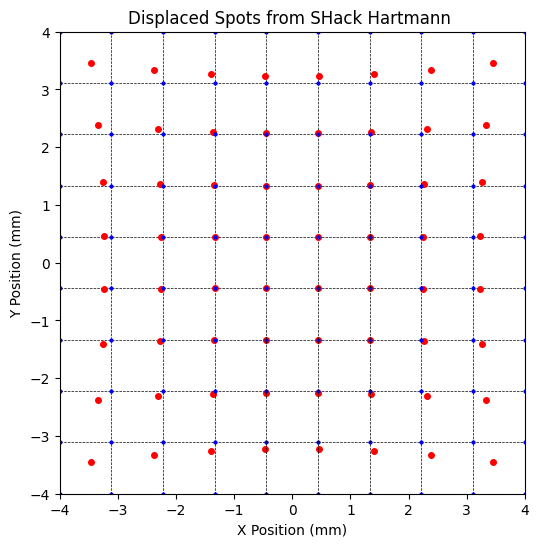

In [20]:
plt.figure(figsize=(6,6))
for i in range(Nlens):
  plt.plot (xx[i,:],yy[i,:],'--',c='black',linewidth = 0.5)
  plt.plot (xx[:,i],yy[:,i],'--',c='black',linewidth = 0.5)
  for j in range(Nlens):
      plt.plot(xx[i,j] + DXY[i,j,0], yy[i,j] + DXY[i,j,1], 'ro', markersize=4)  # Red dots
      plt.plot(xx[i,j] ,yy[i,j], 'bo', markersize=2)  # yellow center dots

# Format plot
plt.xlim(-SD, SD)
plt.ylim(-SD, SD)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Displaced Spots from SHack Hartmann ")
#plt.grid(True)
plt.show()
